# Wine Dataset

This project is aimed to test and compare multiple machine learning algorithms. The algorithms included in this notebook are: Logistic Regression, Linear Discriminant Analysis, Quadratic Discriminant Analysis, Naive bayes. This project comes after successfully implementing these algorithms from scratch and understanding the maths behind each one.

In [35]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

## 1. Load Data

Use pandas to turn the dataset into table.

Observations:
1. `magnesium` and `proline` scale are much bigger than the rest of the features. Which suggests that we need to use `StandartScaler()` to scale the data.

In [12]:
from sklearn.datasets import load_wine

wine_data = load_wine()

X = wine_data.data
y = wine_data.target

print(wine_data.feature_names)
print(wine_data.target_names)
# print(wine_data.DESCR)

print(f"X Shape {X.shape}")
print(f"y Shape {y.shape}")

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
['class_0' 'class_1' 'class_2']
X Shape (178, 13)
y Shape (178,)


In [14]:
FEATURES_NAMES = wine_data.feature_names

df = pd.DataFrame(
    data=X,
    columns=FEATURES_NAMES
)

df['target'] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  target          

In [29]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [24]:
print(f"Target with class value 0 count is: {len(df[df["target"] == 0])}")
print(f"Target with class value 1 count is: {len(df[df["target"] == 1])}")
print(f"Target with class value 2 count is: {len(df[df["target"] == 2])}")
print(f"Total count is: {
    len(df[df["target"] == 0]) + len(df[df["target"] == 1]) + len(df[df["target"] == 2])
}")

Target with class value 0 count is: 59
Target with class value 1 count is: 71
Target with class value 2 count is: 48
Total count is: 178


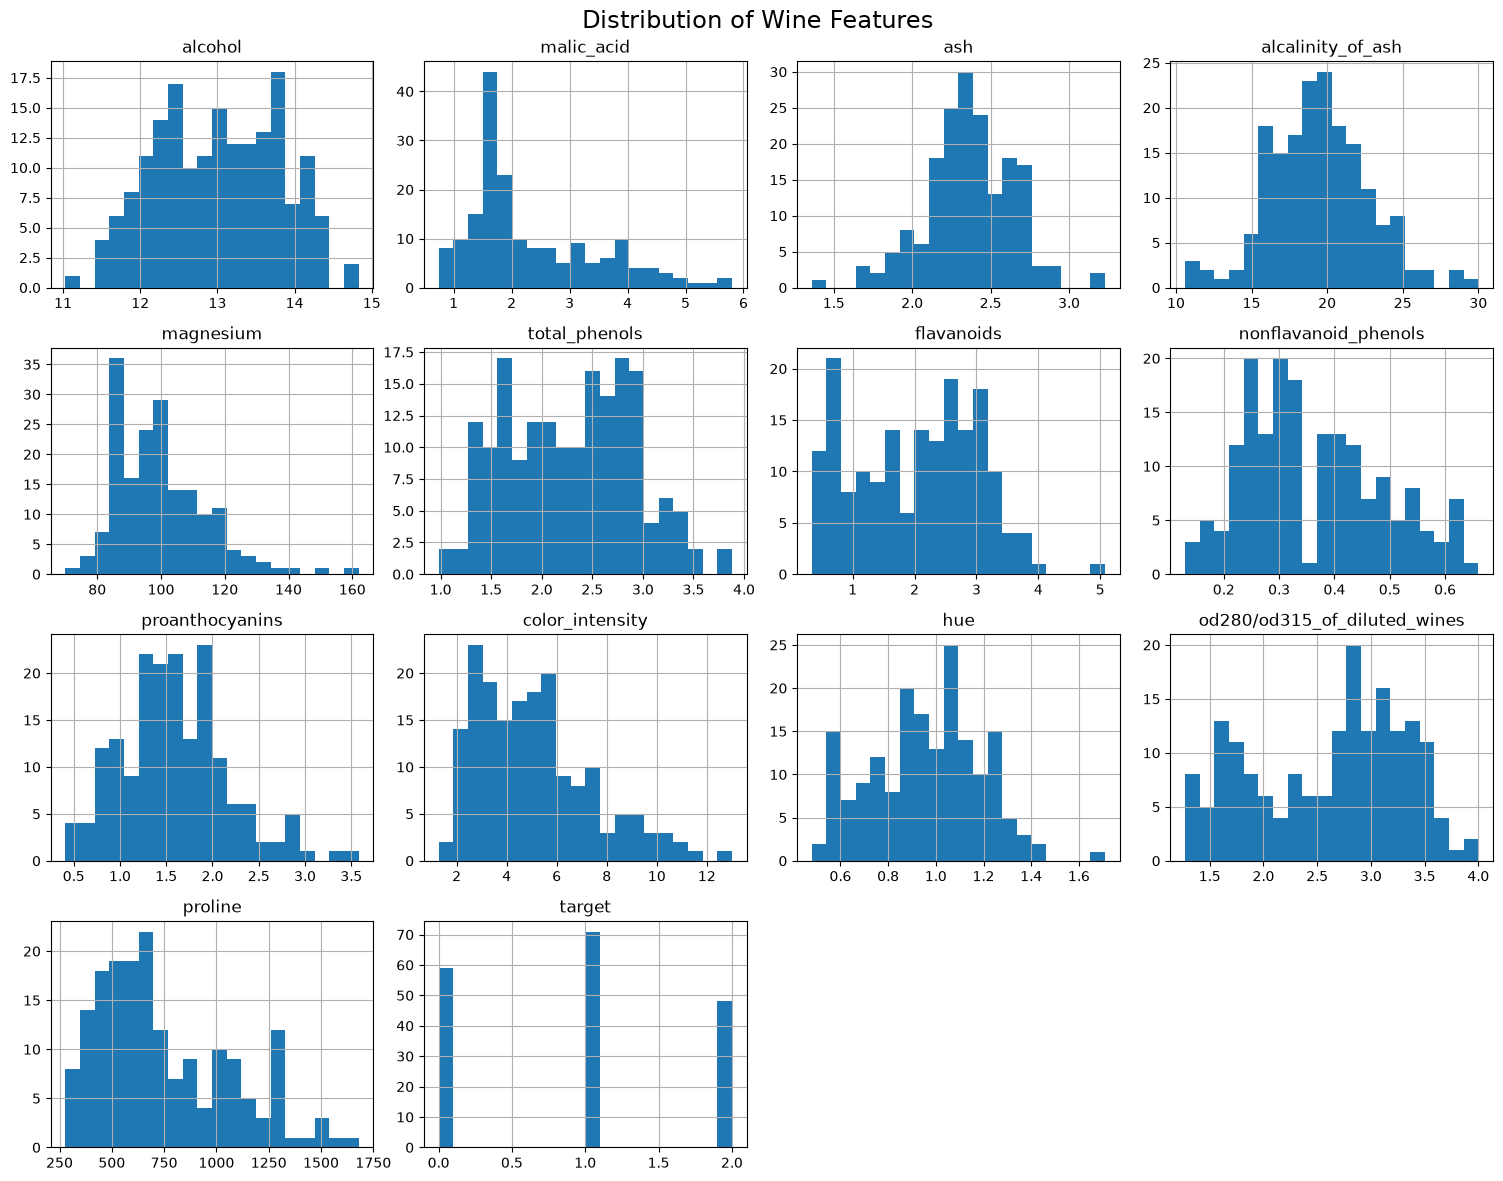

In [28]:
df.hist(figsize=(15, 12), bins=20)
plt.suptitle("Distribution of Wine Features", fontsize=17)
plt.tight_layout()
plt.show()

## Split data into train and test set

`train_test_split` will be used to split the data.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, shuffle=True
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

X_train_scaled shape: (142, 13)
X_test_scaled shape: (36, 13)


In [47]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    # Prediction time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # Testing time
    start = time.time()
    y_pred = model.predict(X_test)
    pred_time = time.time() - start

    return {
        "model_name": model.__class__.__name__,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted"),
        "recall": recall_score(y_test, y_pred, average="weighted"),
        "f1": f1_score(y_test, y_pred, average="weighted"),
        "train_time": train_time,
        "pred_time": pred_time,
        # "y_pred": y_pred
    }

In [54]:
results = []

# Train and Test model on LDA
results.append(
    evaluate_model(
        LinearDiscriminantAnalysis(),
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )
)

# Train and Test model QDA
results.append(
    evaluate_model(
        QuadraticDiscriminantAnalysis(),
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )
)

# Train and Test model Logistic Regression
results.append(
    evaluate_model(
        LogisticRegression(),
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )
)

# Train and Test model Naive Bayes
results.append(
    evaluate_model(
        GaussianNB(),
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test
    )
)

for result in results:
    print(f"\n{"="*40}")
    print(f"Model: {result['model_name']}")
    print(f"{"="*40}")
    print(f"Accuracy: {result['accuracy']:.4f}")
    print(f"Precision: {result['precision']:.4f}")
    print(f"Recall:    {result['recall']:.4f}")
    print(f"F1-Score:  {result['f1']:.4f}")
    print(f"Train Time: {result['train_time']:.4f}s")
    print(f"Pred Time:  {result['pred_time']:.4f}s")


Model: LinearDiscriminantAnalysis
Accuracy: 1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Train Time: 0.0019s
Pred Time:  0.0003s

Model: QuadraticDiscriminantAnalysis
Accuracy: 0.9722
Precision: 0.9741
Recall:    0.9722
F1-Score:  0.9718
Train Time: 0.0012s
Pred Time:  0.0003s

Model: LogisticRegression
Accuracy: 1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
Train Time: 0.0138s
Pred Time:  0.0005s

Model: GaussianNB
Accuracy: 0.9722
Precision: 0.9741
Recall:    0.9722
F1-Score:  0.9722
Train Time: 0.0012s
Pred Time:  0.0003s


In [61]:
def create_comparison_table(results):
    rows = []
    for result in results:
        rows.append({
            'Model': result["model_name"],
            'Accuracy': f"{result['accuracy']:.3f}",
            'Precision': f"{result['precision']:.3f}",
            'Recall': f"{result['recall']:.3f}",
            'F1-Score': f"{result['f1']:.3f}",
            'Train Time (s)': f"{result['train_time']:.4f}",
            'Pred Time (s)': f"{result['pred_time']:.4f}"
        })
    return pd.DataFrame(rows)

In [62]:
create_comparison_table(results)

,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s),Pred Time (s)
0,LinearDiscriminantAnalysis,1.000,1.000,1.000,1.000,0.0019,0.0003
1,QuadraticDiscriminantAnalysis,0.972,0.974,0.972,0.972,0.0012,0.0003
2,LogisticRegression,1.000,1.000,1.000,1.000,0.0138,0.0005
3,GaussianNB,0.972,0.974,0.972,0.972,0.0012,0.0003
